In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

# Kaggle setup
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset download
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import os
!unzip -q brain-tumor-mri-dataset.zip
os.listdir('/content/Testing')

replace Testing/glioma/Te-gl_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

['notumor', 'glioma', 'pituitary', 'meningioma']

In [ ]:
# class distribution
train = "/content/Training"
test = "/content/Testing"

import os
print("Trainig distribution :-")
for i in os.listdir('Training'):
  print(f"{i} : {len(os.listdir(os.path.join(train , i)))}")
print("_________________________________________________________________________________________________________________________")
print("_________________________________________________________________________________________________________________________")

print("Testing distribution :-")
for i in os.listdir("Testing"):
  print(f"{i} : {len(os.listdir(os.path.join(test , i)))}")

Trainig distribution :-
notumor : 1400
glioma : 1400
pituitary : 1400
meningioma : 1400
_________________________________________________________________________________________________________________________
_________________________________________________________________________________________________________________________
Testing distribution :-
notumor : 400
glioma : 400
pituitary : 400
meningioma : 400


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D , Dense , GlobalAveragePooling2D , Flatten , Dropout
from tensorflow.keras.models import Sequential


In [ ]:
# Data preprocessing
# load images
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Training",
    image_size = (224 , 224),
    batch_size = 32,
    subset = 'training',
    shuffle= True,
    validation_split = 0.2,
    labels = 'inferred',
    label_mode = 'int',
    seed = 42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Training",
    image_size = (224,224),
    batch_size = 32 ,
    shuffle = True,
    seed = 42,
    validation_split = 0.2,
    subset = 'validation',
    labels = 'inferred',
    label_mode = 'int'

)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Testing",
    shuffle = False,
    image_size = (224 ,224),
    batch_size =42
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


# EfficientNetB0


In [ ]:
from keras.applications import EfficientNetB0 ,   ResNet101 , DenseNet121
conv_base1 = EfficientNetB0(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224 ,224 ,3)
    )

In [ ]:
conv_base1.trainable = False

In [ ]:
conv_base1.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_18[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# model base layer
eff_model = Sequential([
    conv_base1,
    GlobalAveragePooling2D(),

    Dense(256 , activation = 'relu'),
    Dropout(0.3),
    Dense(256 , activation = 'relu'),
    Dropout(0.3),
    Dense(4 , activation = 'softmax')

])

In [ ]:
# early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True,
)

In [ ]:
eff_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
eff_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,444,327 (16.95 MB)

 Trainable params: 394,756 (1.51 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
eff_history = eff_model.fit(
    train_ds,
    epochs = 20,
    validation_data = validation_ds,
    callbacks = [early_stop]

)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.7786 - loss: 0.5395 - val_accuracy: 0.9098 - val_loss: 0.2680
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8721 - loss: 0.3268 - val_accuracy: 0.9214 - val_loss: 0.2227
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8848 - loss: 0.2866 - val_accuracy: 0.9187 - val_loss: 0.2278
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9078 - loss: 0.2334 - val_accuracy: 0.9438 - val_loss: 0.1670
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9199 - loss: 0.2140 - val_accuracy: 0.9420 - val_loss: 0.1697
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9237 - loss: 0.2026 - val_accuracy: 0.9473 - val_loss: 0.1357
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9301 - loss: 0.1705 - val_accuracy: 0.9571 - val_loss: 0.1367
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9362 - loss: 0.1670 - va

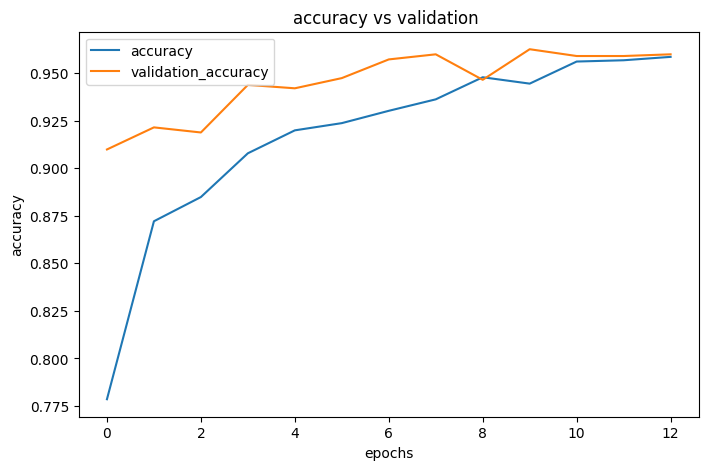

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize =(8,5))
plt.plot(eff_history.history['accuracy'] ,label = 'accuracy')
plt.plot(eff_history.history['val_accuracy'] , label = 'validation_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy vs validation ')
plt.legend()
plt.show()

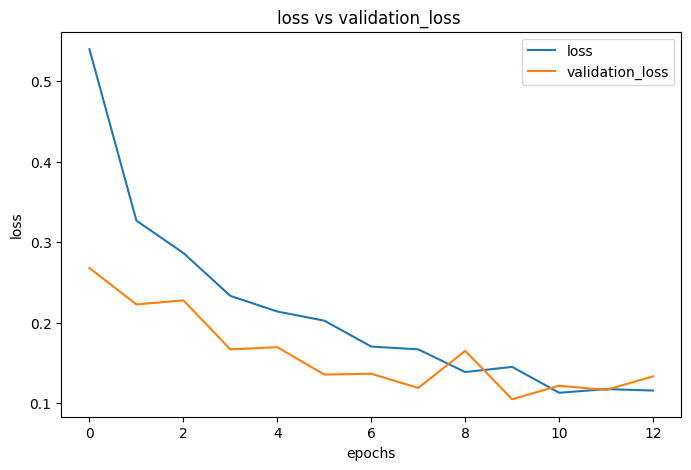

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize =(8,5))
plt.plot(eff_history.history['loss'] ,label = 'loss')
plt.plot(eff_history.history['val_loss'] , label = 'validation_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss vs validation_loss ')
plt.legend()
plt.show()

In [ ]:
eff_loss , eff_accuracy = eff_model.evaluate(test_ds)

39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9081 - loss: 0.3767


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = eff_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


cm = confusion_matrix(y_true, y_pred)

print(cm)

[[280  88  25   7]
 [  8 381   7   4]
 [  0   0 400   0]
 [  2   6   0 392]]


In [ ]:
import numpy as np

classname = train_ds.class_names
img = tf.keras.utils.load_img(
    "/content/Testing/pituitary/Te-pi_242.jpg",
    target_size = (224,224)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array , 0)
pred = eff_model.predict(img_array)
print(f"prediction : {classname[np.argmax(pred)]}")
print(f"confidence : {np.max(pred)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
prediction : pituitary
confidence : 0.9981445074081421


# trying multiple_models


In [ ]:
import matplotlib.pyplot as plt
def base_model(base):
  conv_base = base(
      weights = 'imagenet',
      include_top = False,
      input_shape = (224 ,224, 3)
  )

  conv_base.trainable = False
  conv_base.summary()
  model = Sequential( [
      conv_base ,
      GlobalAveragePooling2D(),

      Dense(256 , activation = 'relu'),
      Dropout(0.3),
      Dense(256 , activation = 'relu'),
      Dropout(0.3),

      Dense(4 , activation = 'softmax') ,
  ])
  model.compile(
      optimizer = 'adam',
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  history = model.fit(
      train_ds,
      epochs = 20,
      validation_data = validation_ds,
      callbacks = [early_stop]
  )

  return model , history


In [ ]:
resnet_model, resnet_history = base_model(ResNet101)

Model: "resnet101"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_20[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 42,658,176 (162.73 MB)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 257ms/step - accuracy: 0.7775 - loss: 0.5752 - val_accuracy: 0.8768 - val_loss: 0.3136
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - accuracy: 0.8634 - loss: 0.3469 - val_accuracy: 0.8884 - val_loss: 0.2855
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step - accuracy: 0.8868 - loss: 0.2919 - val_accuracy: 0.9009 - val_loss: 0.2614


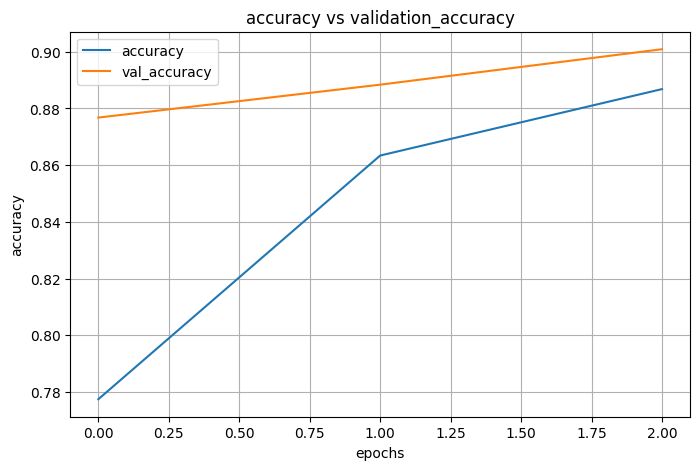

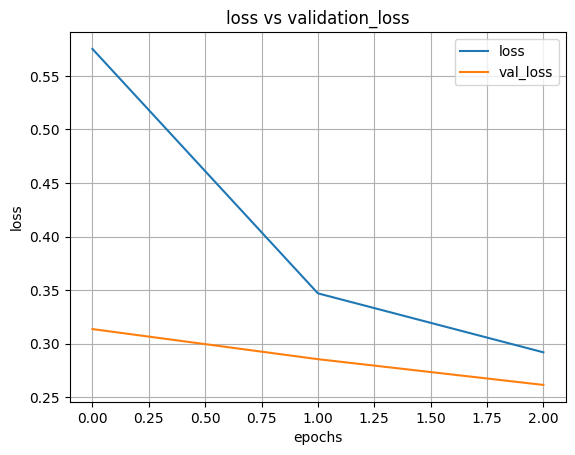

In [ ]:
plt.figure(figsize = (8,5))
plt.plot(resnet_history.history['accuracy'] , label = 'accuracy')
plt.plot(resnet_history.history['val_accuracy'] , label = 'val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title("accuracy vs validation_accuracy")
plt.legend()
plt.grid()
plt.show()



plt.Figure(figsize = (8,5))
plt.plot(resnet_history.history['loss'] , label = 'loss')
plt.plot(resnet_history.history['val_loss'] , label = 'val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("loss vs validation_loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
resnet_loss , resnet_accuracy = resnet_model.evaluate(test_ds)

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 305ms/step - accuracy: 0.8281 - loss: 0.4631


In [ ]:
class_name = train_ds.class_names
img = tf.keras.utils.load_img(
    "/content/Training/notumor/Tr-no_1131.jpg",
    target_size = (224 ,224),

)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array , 0)
pred_model = resnet_model.predict(img_array)
print(f"prediction : {class_name[np.argmax(pred_model)]}")
print(f"confidence : {np.max(pred)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
prediction : notumor
confidence : 0.9999979734420776


# Densenet

In [ ]:
DenseNet_model , DenseNet_history = base_model(DenseNet121)

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_22[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 57s 204ms/step - accuracy: 0.6025 - loss: 1.0896 - val_accuracy: 0.7741 - val_loss: 0.5563
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 103ms/step - accuracy: 0.7605 - loss: 0.6205 - val_accuracy: 0.8589 - val_loss: 0.4070
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.7973 - loss: 0.5239 - val_accuracy: 0.8188 - val_loss: 0.4417


In [ ]:
DenseNet_loss , DenseNet_acc = DenseNet_model.evaluate(test_ds)

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 321ms/step - accuracy: 0.7088 - loss: 0.8048


In [ ]:
class_name = train_ds.class_names
img = tf.keras.utils.load_img(
    "/content/Training/notumor/Tr-no_113.jpg",
    target_size = (224 ,224),

)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array , 0)
pred_model = DenseNet_model.predict(img_array)
print(f"prediction : {class_name[np.argmax(pred_model)]}")
print(f"confidence : {np.max(pred)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
prediction : notumor
confidence : 0.9999979734420776


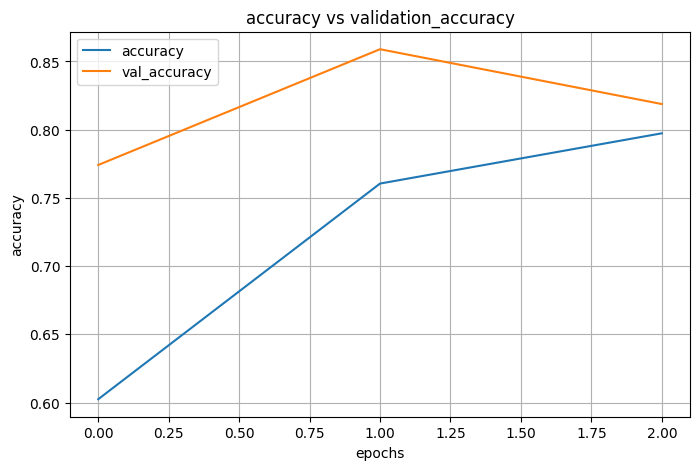

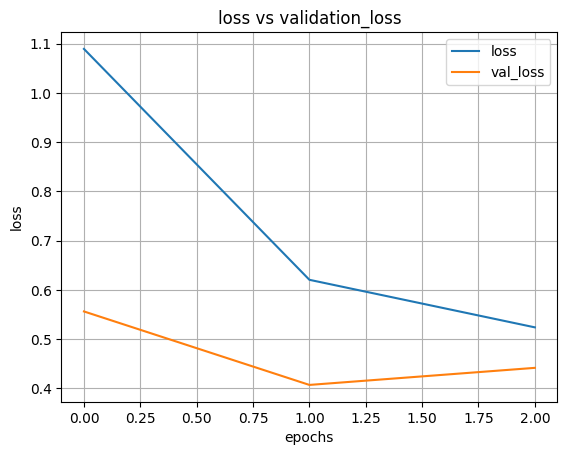

In [ ]:
plt.figure(figsize = (8,5))
plt.plot(DenseNet_history.history['accuracy'] , label = 'accuracy')
plt.plot(DenseNet_history.history['val_accuracy'] , label = 'val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title("accuracy vs validation_accuracy")
plt.legend()
plt.grid()
plt.show()



plt.Figure(figsize = (8,5))
plt.plot(DenseNet_history.history['loss'] , label = 'loss')
plt.plot(DenseNet_history.history['val_loss'] , label = 'val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("loss vs validation_loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("EfficientNetB0:", eff_accuracy)
print("ResNet101:", resnet_accuracy)
print("DenseNet121:", DenseNet_acc)

EfficientNetB0: 0.9081249833106995
ResNet101: 0.828125
DenseNet121: 0.7087500095367432


In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    "Model" : ["EfficientNet80" , "ResNet101" , "DenseNet"],
    "Accuracy":[eff_accuracy , resnet_accuracy , DenseNet_acc]
})

comparison

,Model,Accuracy
0,EfficientNet80,0.908125
1,ResNet101,0.828125
2,DenseNet,0.708750


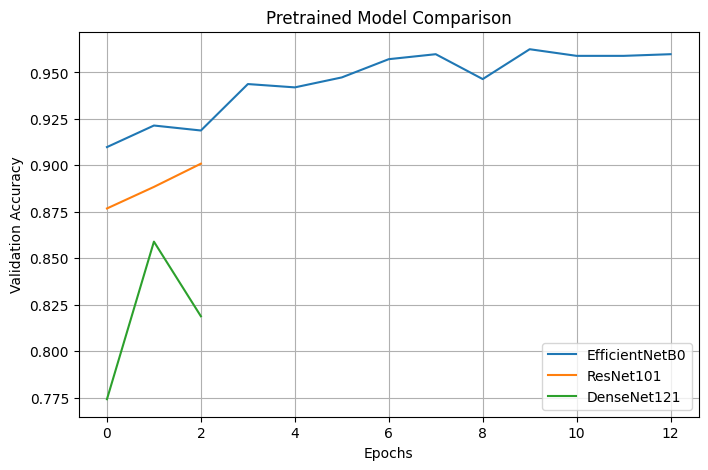

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    eff_history.history['val_accuracy'],
    label='EfficientNetB0'
)

plt.plot(
    resnet_history.history['val_accuracy'],
    label='ResNet101'
)

plt.plot(
    DenseNet_history.history['val_accuracy'],
    label='DenseNet121'
)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Pretrained Model Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
final_model = eff_model

In [ ]:
final_model.save("brain_tumor_model.keras")